In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import torch

In [3]:
device = torch.device('cpu') if not torch.accelerator.is_available() else torch.accelerator.current_accelerator()
print(device)

cuda


# Hyperparameters

In [4]:
batch_size = 128
resize = (96, 96)
num_epochs = 10
lr = 0.001

# Load dataset

In [5]:
from utils.data import CIFAR10
from utils.train import train_model, val_stats

def get_optimizer(model):
    return torch.optim.Adam(model.parameters(), lr=lr)

def fit(model, num_epochs=num_epochs):
    dataset = CIFAR10(batch_size=batch_size, resize=resize, device=device)
    train_dl, val_dl = dataset.get_dataloaders()
    optimizer = get_optimizer(model)
    return train_model(model, train_dl, val_dl, optimizer, num_epochs)

# Create model

In [6]:
from torch import nn
import torch.nn.functional as F
from utils.models import Module

#### Dense Block

In [7]:
def conv_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(), 
        nn.LazyConv2d(num_channels, kernel_size=3, padding=1))

class DenseBlock(nn.Module):
    def __init__(self, num_convs, num_channels):
        super().__init__()
        convs = []
        for i in range(num_convs):
            convs.append(conv_block(num_channels))
        self.convs = nn.Sequential(*convs)
    
    def forward(self, X):
        for conv in self.convs:
            Y = conv(X)
            X = torch.cat((X, Y), dim=1)
        return X

In [8]:
blk = DenseBlock(2, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
print(Y.shape)

torch.Size([4, 23, 8, 8])


### Transition Block

In [9]:
def transition_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2)
    )

In [10]:
blk = transition_block(10)
print(blk(Y).shape)

torch.Size([4, 10, 4, 4])


## DenseNet Model

In [11]:
class DenseNet(Module):
    def __init__(self, num_channels=64, growth_rate=32, arch=(4, 4, 4, 4), num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.net = nn.Sequential(self.stem(num_channels))
        for i, num_convs in enumerate(arch):
            self.net.add_module(f"dense_blk{i+1}", DenseBlock(num_convs, growth_rate))
            num_channels += num_convs * growth_rate
            if i != len(arch) - 1:
                num_channels //= 2
                self.net.add_module(f"transition_blk{i+1}", transition_block(num_channels))
            print(num_channels)
        self.net.add_module("Head", self.head())
        
    def stem(self, num_channels):
        return nn.Sequential(nn.LazyConv2d(num_channels, kernel_size=7, padding=3, stride=2),
                             nn.LazyBatchNorm2d(), nn.ReLU(),
                             nn.MaxPool2d(kernel_size=3, padding=1, stride=2))

    def head(self):
        return nn.Sequential(
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)), 
            nn.Flatten(), 
            nn.LazyLinear(self.num_classes)
        )

    def forward(self, X):
        return self.net(X)

In [12]:
model = DenseNet().to(device)
X = torch.randn(batch_size, 3, *resize).to(device)

96
112
120
248


In [13]:
with torch.no_grad():
    print(model(X).shape)

print(model)

torch.Size([128, 10])
DenseNet(
  (net): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (dense_blk1): DenseBlock(
      (convs): Sequential(
        (0): Sequential(
          (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
          (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (1): Sequential(
          (0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
          (2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (2): Sequential(
          (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [14]:
num_params = sum(p.numel() for p in model.parameters())
print(num_params)
print(f"Parameter memory: {num_params * 4 / 1e6:.0f} MB")

764498
Parameter memory: 3 MB


# Train model

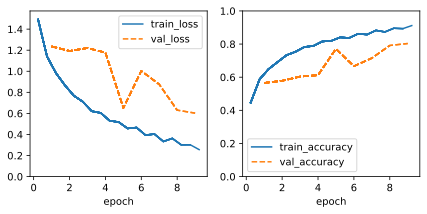

In [ ]:
fit(model);

In [ ]:
_, val_dl = CIFAR10(batch_size=batch_size, resize=resize, device=device).get_dataloaders()
val_loss, val_accuracy = val_stats(model, val_dl, device=device)

In [ ]:
print(f"Validation loss: {val_loss:.2f}, accuracy: {val_accuracy:.2f}%")

# How much memory usage during training?

In [ ]:
print(f"Max memory allocated: {torch.cuda.max_memory_allocated()/1e9:.3f} GB")